In [74]:
import os, pickle

from physics.simulation import mcfm, msq
from physics.hzz import zpair, zz4l
from datasets import balanced
from models import carl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import hist

import torch
from torch.utils.data import Dataset
import lightning

In [75]:
OUTPUT_DIR = '../jobs/carl/refactor-three-qqZZ-SBI-3M'
SCALER_FILE_X = 'scaler.pkl'
SCALER_FILE_Y = None
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../../data'

EPOCH = '21'
VAL_LOSS = 0.68
VERSION = 2

CHECKPOINT = f'checkpoint-carl-epoch={EPOCH}-val_loss={VAL_LOSS}.ckpt'
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

SAMPLE_SIZE = 500000

FEATURES=['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
          'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
          'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
          'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

BATCH_SIZE = 256
SEED = 42

In [76]:
events_numerator = mcfm.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, 'qqZZ2e2m.csv'), n_rows=1.2*SAMPLE_SIZE)
events_denominator = mcfm.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, 'ggZZ2e2m_sbi.csv'), n_rows=1.2*SAMPLE_SIZE)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()
lepton_momenta = zz4l.LeptonMomenta()

events_numerator = events_numerator.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars).calculate(lepton_momenta)
events_denominator = events_denominator.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars).calculate(lepton_momenta)

events_num_train, events_num_val = events_numerator.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)
events_den_train, events_den_val = events_denominator.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)

training_data = balanced.BalancedDataset(events_num_train, events_den_train, FEATURES, SAMPLE_SIZE, SEED)
validation_data = balanced.BalancedDataset(events_num_val, events_den_val, FEATURES, SAMPLE_SIZE, SEED)

if SCALER_FILE_X is not None:
    with open(os.path.join(OUTPUT_DIR, SCALER_FILE_X), 'rb') as f:
        scaler_X = pickle.load(f)
    
    training_data.X = scaler_X.transform(training_data.X)
    validation_data.X = scaler_X.transform(validation_data.X)

31.49779940929351
3.199992437926865


In [77]:
print(training_data.X.shape)

(1000000, 16)


In [78]:
loaded_model = carl.CARL.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

dl_train = torch.utils.data.DataLoader(training_data, batch_size=BATCH_SIZE)
dl_val = torch.utils.data.DataLoader(validation_data, batch_size=BATCH_SIZE)

trainer = lightning.Trainer(accelerator='cpu')

predictions_train = torch.concatenate(trainer.predict(loaded_model, dataloaders=[dl_train]), axis=0).detach().numpy()

predictions_val = torch.concatenate(trainer.predict(loaded_model, dataloaders=[dl_val]), axis=0).detach().numpy()

ratios_train_pred = predictions_train/(1-predictions_train)

ratios_val_pred = predictions_val/(1-predictions_val)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 3907/3907 [04:28<00:00, 14.53it/s]


In [79]:
targets_train = training_data.s
targets_val = validation_data.s

/tmp/ipykernel_103217/105109266.py:14: RuntimeWarning: divide by zero encountered in log
  truth_ratios = [np.log(sig_per_bin[i]/bkg_per_bin[i]) for i in range(bins)]


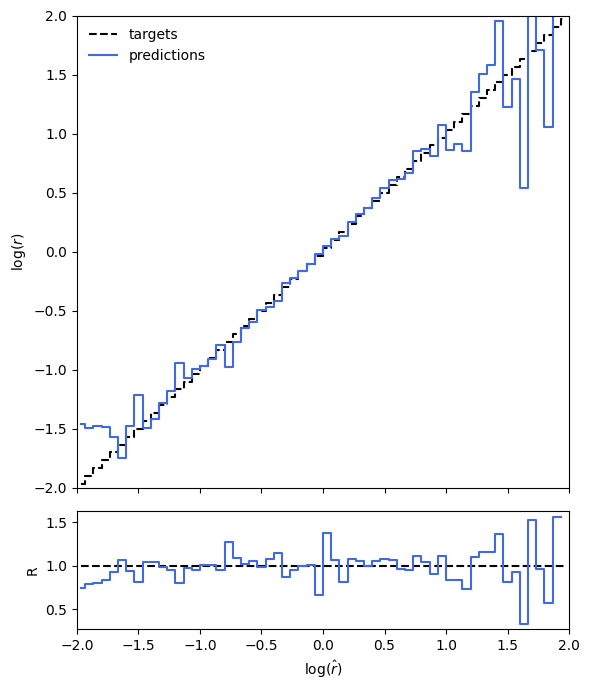

In [ ]:
bins = 60
bounds = [-2,2]
step_size = (bounds[1]-bounds[0])/bins

p = np.log(ratios_train_pred)
t = targets_train

pred_binned = [p[(p > bounds[0]+step_size*i)&(p <= bounds[0]+step_size*(i+1))] for i in range(bins)]
targets_binned = [t[(p > bounds[0]+step_size*i)&(p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

sig_per_bin = [np.sum(targets_binned[i]==1.0)/len(targets_binned[i]) for i in range(bins)]
bkg_per_bin = [np.sum(targets_binned[i]==0.0)/len(targets_binned[i]) for i in range(bins)]

truth_ratios = [np.log(sig_per_bin[i]/bkg_per_bin[i]) for i in range(bins)]

pred_ratios_avg = [np.mean(pred_binned[i]) for i in range(bins)]

centers = [bounds[0]+(i+1/2)*step_size for i in range(bins)]

h = hist.Hist(hist.axis.Regular(bins, *bounds))
h.fill(np.log(ratios_train_pred))

#h.plot(color='black', linestyle='--')

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4,1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, centers, color='black', linestyle='--', drawstyle='steps-mid', label='targets')
ax1.errorbar(centers, truth_ratios, color='royalblue', drawstyle='steps-mid', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$\log(r)$')

ax1.legend(frameon=False)

ax2.errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', drawstyle='steps-mid', label='targets')
ax2.errorbar(centers, np.array(truth_ratios)-np.array(centers), color='royalblue', drawstyle='steps-mid', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$\log(\hat{r})$')
ax2.set_ylabel('Residual')

plt.tight_layout()
plt.show()

In [81]:
print(np.sum(np.array(pred_ratios_num)!=0.0))

36
